# Câmara dos Deputados 2022: votos x cadeiras

Visualização da **(des)proporcionalidade** do sistema eleitoral brasileiro: para cada partido (ou federação), comparamos o percentual de votos válidos recebidos com o percentual de cadeiras obtidas na Câmara dos Deputados (513 cadeiras), no 1º turno de 2022.

**Fonte (TSE — Portal de Dados Abertos, Eleições 2022):**
- Votos por partido: `votacao_partido.csv` — <https://dadosabertos.tse.jus.br/dataset/resultados-2022>
- Candidatos eleitos: `consulta_cand_2022/consulta_cand_2022_BRASIL.csv` — <https://dadosabertos.tse.jus.br/dataset/candidatos-2022>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Patch

CAD_TOTAL = 513

## 1. Votos válidos por partido (Deputado Federal, 1º turno)

In [2]:
votos = pd.read_csv("votacao_partido.csv", sep=";", encoding="latin-1")
votos = votos[(votos["Cargo"] == "Deputado Federal") & (votos["Turno"] == 1)]
votos = (votos.groupby("Sigla partido")["Quantidade de votos válidos"]
              .sum().rename("votos").reset_index()
              .rename(columns={"Sigla partido": "partido"}))
votos.head()

,partido,votos
0,AGIR,158868
1,AVANTE,2192518
2,CIDADANIA,1614106
3,DC,97741
4,MDB,7950895


## 2. Cadeiras por partido (candidatos eleitos)

In [3]:
cand = pd.read_csv("consulta_cand_2022/consulta_cand_2022_BRASIL.csv",
                   sep=";", encoding="latin-1", low_memory=False)
eleitos = cand[(cand["DS_CARGO"].str.upper() == "DEPUTADO FEDERAL") &
               (cand["DS_SIT_TOT_TURNO"].str.upper().isin(
                   ["ELEITO POR QP", "ELEITO POR MÉDIA", "ELEITO"]))]
cadeiras = (eleitos.groupby("SG_PARTIDO").size().rename("cadeiras").reset_index()
                   .rename(columns={"SG_PARTIDO": "partido"}))
cadeiras.sort_values("cadeiras", ascending=False).head()

,partido,cadeiras
7,PL,100
16,PT,68
22,UNIÃO,58
9,PP,47
2,MDB,42


## 3. Junta, agrupa as federações e calcula o desvio de representação

Em 2022 as federações partidárias disputaram como **lista única** no quociente eleitoral, então votos e cadeiras são consolidados por bloco (FE Brasil = PT+PCdoB+PV; PSDB-Cidadania; PSOL-REDE).

`desvio = % de cadeiras − % de votos` (em pontos percentuais). Positivo = super-representado; negativo = sub-representado.

In [4]:
FEDERACOES = {
    "PT": "FE Brasil", "PC do B": "FE Brasil", "PV": "FE Brasil",
    "PSDB": "PSDB-Cidadania", "CIDADANIA": "PSDB-Cidadania",
    "PSOL": "PSOL-REDE", "REDE": "PSOL-REDE",
}

df = votos.merge(cadeiras, on="partido", how="left")
df["cadeiras"] = df["cadeiras"].fillna(0).astype(int)
df["partido"] = df["partido"].map(FEDERACOES).fillna(df["partido"])
df = df.groupby("partido", as_index=False)[["votos", "cadeiras"]].sum()
df["pct_votos"] = 100 * df["votos"] / df["votos"].sum()
df["pct_cadeiras"] = 100 * df["cadeiras"] / CAD_TOTAL
df["desvio"] = df["pct_cadeiras"] - df["pct_votos"]
df = df.sort_values("desvio")  # sub-representados embaixo, super-representados no topo

assert df["cadeiras"].sum() == CAD_TOTAL, df["cadeiras"].sum()
df.sort_values("desvio", ascending=False)[["partido", "pct_votos", "cadeiras", "pct_cadeiras", "desvio"]]

,partido,pct_votos,cadeiras,pct_cadeiras,desvio
10,PL,16.609551,100,19.493177,2.883626
26,UNIÃO,9.301557,58,11.306043,2.004485
3,FE Brasil,14.040324,80,15.594542,1.554218
14,PP,7.930661,47,9.161793,1.231132
24,REPUBLICANOS,6.963346,41,7.992203,1.028857
4,MDB,7.274419,42,8.187135,0.912716
19,PSD,7.588292,42,8.187135,0.598843
8,PCO,0.006686,0,0.000000,-0.006686
22,PSTU,0.025613,0,0.000000,-0.025613
27,UP,0.049942,0,0.000000,-0.049942


## 4. Visualização: barras divergentes

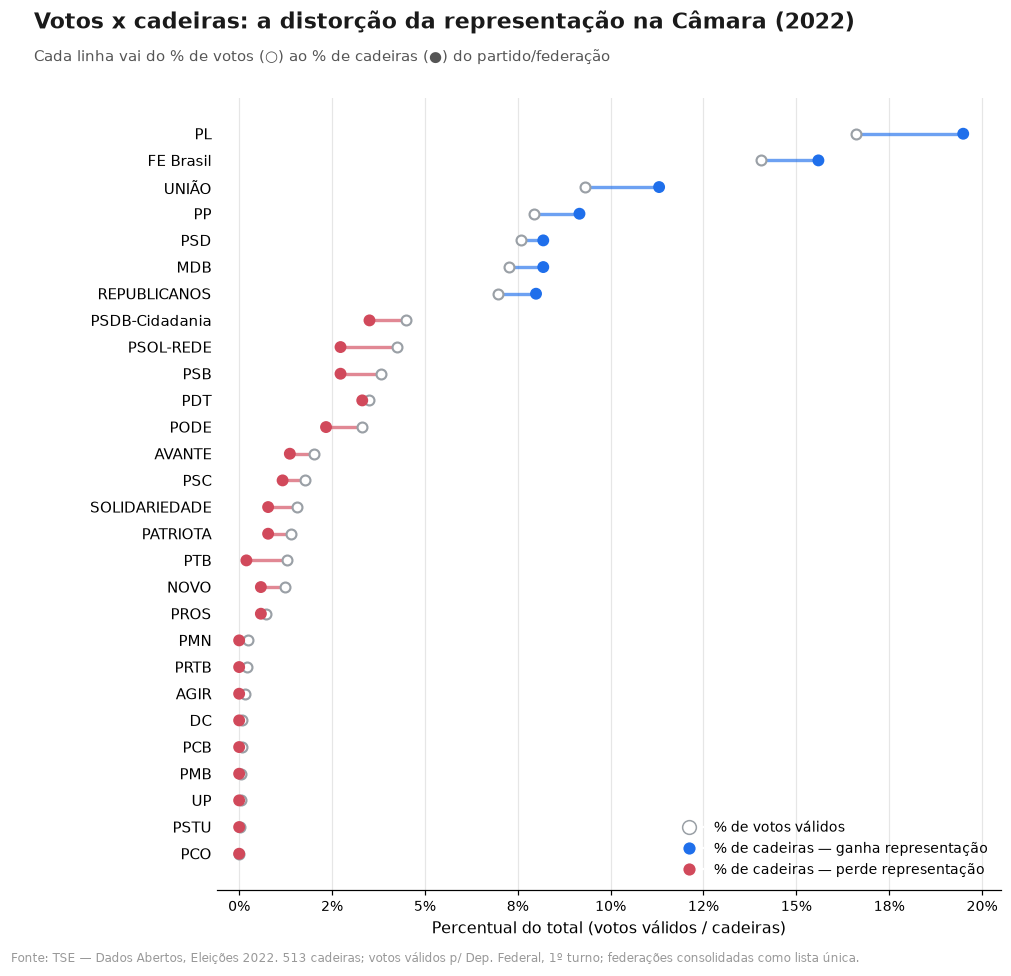

In [5]:
from matplotlib.lines import Line2D

OVER, UNDER, VOTO = "#1f6feb", "#d1495b", "#9aa0a6"
d = df.sort_values("pct_votos")  # menores embaixo, maiores no topo
y = range(len(d))

fig, ax = plt.subplots(figsize=(9.5, 9), dpi=110)
ax.grid(axis="x", color="#e6e6e6", lw=0.8, zorder=0)
ax.set_axisbelow(True)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)

cor_cad = [OVER if c >= v else UNDER for v, c in zip(d["pct_votos"], d["pct_cadeiras"])]
for i, (v, c, col) in enumerate(zip(d["pct_votos"], d["pct_cadeiras"], cor_cad)):
    ax.plot([v, c], [i, i], color=col, lw=2.2, alpha=0.65, zorder=2)
ax.scatter(d["pct_votos"], list(y), s=42, facecolor="white", edgecolor=VOTO,
           linewidth=1.4, zorder=3)
ax.scatter(d["pct_cadeiras"], list(y), s=46, color=cor_cad, zorder=4)

ax.set_yticks(list(y))
ax.set_yticklabels(d["partido"])
ax.set_xlim(-0.6, 20.5)
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.tick_params(axis="y", length=0, labelsize=9.5)
ax.tick_params(axis="x", labelsize=9)
ax.set_xlabel("Percentual do total (votos válidos / cadeiras)", fontsize=10.5)

fig.text(0.035, 0.955, "Votos x cadeiras: a distorção da representação na Câmara (2022)",
         fontsize=14.5, fontweight="bold", color="#1a1a1a")
fig.text(0.035, 0.922, "Cada linha vai do % de votos (○) ao % de cadeiras (●) do partido/federação",
         fontsize=10, color="#555")

ax.legend(handles=[
    Line2D([0], [0], marker="o", color="w", markerfacecolor="white",
           markeredgecolor=VOTO, markersize=9, label="% de votos válidos"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=OVER, markersize=9,
           label="% de cadeiras — ganha representação"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=UNDER, markersize=9,
           label="% de cadeiras — perde representação")],
    loc="lower right", frameon=False, fontsize=9)

fig.text(0.013, 0.012,
         "Fonte: TSE — Dados Abertos, Eleições 2022. 513 cadeiras; votos válidos p/ Dep. Federal, "
         "1º turno; federações consolidadas como lista única.",
         fontsize=8, color="#999")

fig.subplots_adjust(left=0.21, right=0.96, top=0.885, bottom=0.085)
fig.savefig("vis-camara-2022.svg")
fig.savefig("vis-camara-2022.png", dpi=150)
plt.show()